<a href="https://colab.research.google.com/github/cuctuyetaz258/Cross-Domain-Video-Highlight-Agent/blob/main/week1/FeatureExtraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q librosa soundfile yt-dlp pydantic
!apt-get -y -qq install ffmpeg > /dev/null


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 25.3 MB/s eta 0:00:00


In [2]:
import os
import json
import glob
import warnings
from dataclasses import dataclass, field, asdict
from abc import ABC, abstractmethod
from typing import List, Dict, Optional

import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)

print("librosa:", librosa.__version__)


librosa: 0.11.0


In [3]:
@dataclass
class FeatureWindow:
    """Điểm số của MỘT tầng đặc trưng cho MỘT cửa sổ thời gian."""
    start: float
    end: float
    score: float
    details: Dict[str, float] = field(default_factory=dict)

    def to_dict(self):
        return asdict(self)


class FeatureLayer(ABC):
    """Lớp cơ sở (abstract) cho MỘT trong 5 tầng đặc trưng — xem chi tiết ở Buổi 1."""
    name: str = "base"

    def __init__(self, weight: float = 1.0):
        self.weight = weight

    @abstractmethod
    def extract(self, window_sec: float = 30.0, hop_sec: float = 15.0, **kwargs) -> List[FeatureWindow]:
        raise NotImplementedError


class AcousticLayer(FeatureLayer):
    """Tầng Âm học — TRIỂN KHAI ĐẦY ĐỦ ở mục 3-4 của notebook này."""
    name = "acoustic"

    def extract(self, window_sec=30.0, hop_sec=15.0, **kwargs):
        raise NotImplementedError("Sẽ được ghi đè bởi AcousticFeatureExtractor bên dưới")


class AudioConfig:
    SR = 16000            # 16kHz mono — khớp với output ffmpeg của Backend (Bước 2 pipeline)
    WINDOW_SEC = 30.0      # độ dài cửa sổ trượt — khớp Bước 5 pipeline ("cửa sổ trượt 30s")
    HOP_SEC = 15.0         # bước nhảy (50% overlap)
    FRAME_LENGTH = 2048    # cho RMS / pyin
    HOP_LENGTH = 512
    SILENCE_TOP_DB = 30    # ngưỡng (dB dưới đỉnh) coi là khoảng lặng cho librosa.effects.split


def load_audio(path: str, sr: int = AudioConfig.SR) -> (np.ndarray, int):
    y, sr = librosa.load(path, sr=sr, mono=True)
    return y, sr


def make_windows(duration_sec: float, window_sec: float = AudioConfig.WINDOW_SEC,
                  hop_sec: float = AudioConfig.HOP_SEC) -> List[tuple]:
    windows = []
    t = 0.0
    while t < duration_sec:
        start, end = t, min(t + window_sec, duration_sec)
        if end - start >= window_sec / 3:
            windows.append((start, end))
        t += hop_sec
    return windows


print(f"Config: SR={AudioConfig.SR}Hz | window={AudioConfig.WINDOW_SEC}s | hop={AudioConfig.HOP_SEC}s")


Config: SR=16000Hz | window=30.0s | hop=15.0s


In [13]:
import os
import numpy as np
import soundfile as sf

os.makedirs("sample_data/podcast", exist_ok=True)

sr = 16000
duration = 90
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
audio_signal = 0.1 * np.sin(2 * np.pi * 440 * t) + 0.05 * np.random.randn(len(t))

output_path = "sample_data/podcast/synthetic_demo.wav"
sf.write(output_path, audio_signal, sr)

print(f" Đã tạo file âm thanh giả lập dự phòng tại: {output_path}")

 Đã tạo file âm thanh giả lập dự phòng tại: sample_data/podcast/synthetic_demo.wav


## 2. Lấy file audio để phân tích

Ưu tiên dùng file thật đã tải ở Buổi 1 (thư mục `sample_data/...`). Nếu chưa có, tự sinh audio giả
lập để demo pipeline không phụ thuộc mạng.

In [14]:
DATA_ROOT = "sample_data"
for domain in ["lecture", "podcast", "standup"]:
    os.makedirs(os.path.join(DATA_ROOT, domain), exist_ok=True)


def find_existing_audio() -> Optional[str]:
    matches = glob.glob(os.path.join(DATA_ROOT, "*", "*.wav"))
    return matches[0] if matches else None


def make_synthetic_audio() -> str:
    sr = AudioConfig.SR
    duration = 90  # giây
    t = np.linspace(0, duration, int(sr * duration))
    signal = np.zeros_like(t)
    segments = [(0, 20, 220, 0.15), (25, 50, 320, 0.35), (55, 85, 180, 0.10)]
    for s, e, f0, amp in segments:
        mask = (t >= s) & (t < e)
        vibrato = 1 + 0.15 * np.sin(2 * np.pi * 4 * t[mask])
        signal[mask] = amp * np.sin(2 * np.pi * f0 * vibrato * t[mask])
    signal += 0.005 * np.random.randn(len(signal))

    demo_path = os.path.join(DATA_ROOT, "podcast", "synthetic_demo.wav")
    sf.write(demo_path, signal, sr)
    return demo_path


demo_audio_path = find_existing_audio() or make_synthetic_audio()
print("Audio dùng để phân tích:", demo_audio_path)


Audio dùng để phân tích: sample_data/podcast/synthetic_demo.wav


In [15]:
def compute_rms_energy(y: np.ndarray, sr: int, start: float, end: float) -> float:
    seg = y[int(start * sr): int(end * sr)]
    if len(seg) == 0:
        return 0.0
    rms = librosa.feature.rms(y=seg, frame_length=AudioConfig.FRAME_LENGTH,
                               hop_length=AudioConfig.HOP_LENGTH)[0]
    return float(np.mean(rms))


def compute_pitch_variation(y: np.ndarray, sr: int, start: float, end: float) -> float:
    seg = y[int(start * sr): int(end * sr)]
    if len(seg) < AudioConfig.FRAME_LENGTH:
        return 0.0
    f0, voiced_flag, _ = librosa.pyin(
        seg, fmin=librosa.note_to_hz("C2"), fmax=librosa.note_to_hz("C7"),
        frame_length=AudioConfig.FRAME_LENGTH, hop_length=AudioConfig.HOP_LENGTH,
    )
    voiced_f0 = f0[voiced_flag] if f0 is not None else np.array([])
    voiced_f0 = voiced_f0[~np.isnan(voiced_f0)]
    if len(voiced_f0) < 2:
        return 0.0
    return float(np.std(voiced_f0))


def compute_silence_duration(y: np.ndarray, sr: int, start: float, end: float,
                              top_db: int = AudioConfig.SILENCE_TOP_DB) -> float:
    seg = y[int(start * sr): int(end * sr)]
    if len(seg) == 0:
        return 0.0
    non_silent = librosa.effects.split(seg, top_db=top_db)
    voiced_samples = sum(e - s for s, e in non_silent)
    silence_samples = len(seg) - voiced_samples
    return float(silence_samples / sr)


class AcousticFeatureExtractor(AcousticLayer):
    """Triển khai đầy đủ tầng Âm học: RMS energy, pitch variation, silence duration -> Acoustic Score."""

    def __init__(self, audio_path: str, weight: float = 1.0):
        super().__init__(weight=weight)
        self.audio_path = audio_path
        self.y, self.sr = load_audio(audio_path)
        self.duration = librosa.get_duration(y=self.y, sr=self.sr)

    def _raw_features(self, window_sec, hop_sec) -> List[Dict]:
        windows = make_windows(self.duration, window_sec, hop_sec)
        raw = []
        for start, end in windows:
            raw.append({
                "start": start,
                "end": end,
                "rms": compute_rms_energy(self.y, self.sr, start, end),
                "pitch_var": compute_pitch_variation(self.y, self.sr, start, end),
                "silence_sec": compute_silence_duration(self.y, self.sr, start, end),
            })
        return raw

    @staticmethod
    def _normalize(values: List[float]) -> List[float]:
        arr = np.array(values, dtype=float)
        lo, hi = arr.min(), arr.max()
        if hi - lo < 1e-9:
            return [0.5] * len(arr)  # không đủ biến thiên -> điểm trung lập
        return list((arr - lo) / (hi - lo))

    def extract(self, window_sec: float = AudioConfig.WINDOW_SEC,
                hop_sec: float = AudioConfig.HOP_SEC, **kwargs) -> List[FeatureWindow]:
        raw = self._raw_features(window_sec, hop_sec)
        rms_norm = self._normalize([r["rms"] for r in raw])
        pitch_norm = self._normalize([r["pitch_var"] for r in raw])
        # khoảng lặng NHIỀU -> nhấn giọng ÍT hơn, nên đảo dấu sau khi chuẩn hoá
        silence_norm = self._normalize([r["silence_sec"] for r in raw])
        silence_score = [1 - s for s in silence_norm]

        results = []
        for i, r in enumerate(raw):
            # Acoustic Score = trung bình có trọng số của 3 tín hiệu (đều đóng góp "mức nhấn giọng")
            acoustic_score = float(np.mean([rms_norm[i], pitch_norm[i], silence_score[i]]))
            results.append(FeatureWindow(
                start=r["start"], end=r["end"], score=acoustic_score,
                details={
                    "rms_raw": r["rms"], "pitch_var_raw": r["pitch_var"], "silence_sec_raw": r["silence_sec"],
                    "rms_norm": rms_norm[i], "pitch_var_norm": pitch_norm[i], "silence_score_norm": silence_score[i],
                }
            ))
        return results


print("Đã định nghĩa AcousticFeatureExtractor (RMS + pitch variation + silence duration).")


Đã định nghĩa AcousticFeatureExtractor (RMS + pitch variation + silence duration).


## 4. Chạy thử: trả về Acoustic Score cho mỗi cửa sổ

In [8]:
acoustic_extractor = AcousticFeatureExtractor(demo_audio_path)
acoustic_windows = acoustic_extractor.extract()

print(f"{len(acoustic_windows)} cửa sổ | audio: {demo_audio_path} | thời lượng: {acoustic_extractor.duration:.1f}s\n")
print(f"{'Start':>7} {'End':>7} {'AcousticScore':>14} {'RMS':>8} {'PitchVar':>10} {'Silence(s)':>11}")
for w in acoustic_windows:
    d = w.details
    print(f"{w.start:7.1f} {w.end:7.1f} {w.score:14.3f} {d['rms_raw']:8.4f} {d['pitch_var_raw']:10.2f} {d['silence_sec_raw']:11.2f}")


6 cửa sổ | audio: sample_data/podcast/synthetic_demo.wav | thời lượng: 90.0s

  Start     End  AcousticScore      RMS   PitchVar  Silence(s)
    0.0    30.0          0.605   0.0865       6.31        0.00
   15.0    45.0          0.662   0.0866       6.34        0.00
   30.0    60.0          0.453   0.0865       5.99        0.00
   45.0    75.0          0.342   0.0865       6.37        0.00
   60.0    90.0          0.572   0.0865       6.71        0.00
   75.0    90.0          0.619   0.0865       6.71        0.00


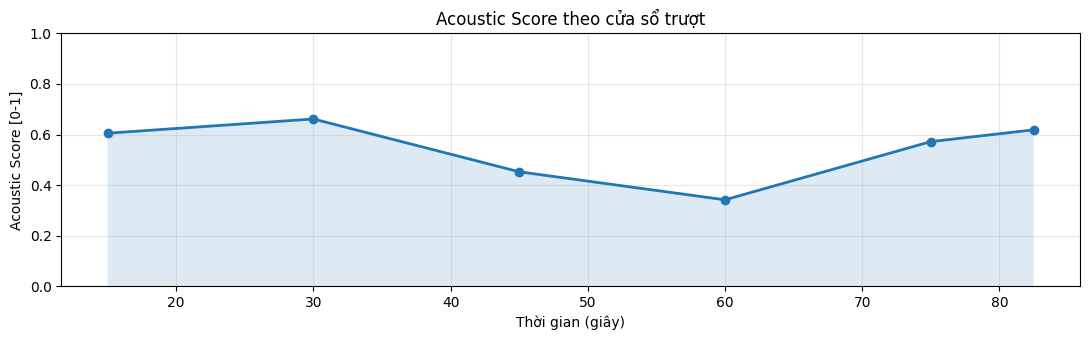

In [11]:

times = [(w.start + w.end) / 2 for w in acoustic_windows]
scores = [w.score for w in acoustic_windows]

plt.figure(figsize=(11, 3.5))
plt.plot(times, scores, marker="o", linewidth=2)
plt.fill_between(times, scores, alpha=0.15)
plt.xlabel("Thời gian (giây)")
plt.ylabel("Acoustic Score [0-1]")
plt.title("Acoustic Score theo cửa sổ trượt")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Xuất kết quả JSON để bàn giao cho pipeline chung

Lưu kết quả theo schema đơn giản để Model Lead (Tuyết) ghép vào `AgentState` chung của LangGraph,
và để bước tổng hợp `Score(t) = Σ wᵢ × fᵢ(t)` ở Bước 6 dùng trực tiếp.

In [12]:
os.makedirs("outputs", exist_ok=True)

output_payload = {
    "layer": "acoustic",
    "audio_path": demo_audio_path,
    "sample_rate": acoustic_extractor.sr,
    "window_sec": AudioConfig.WINDOW_SEC,
    "hop_sec": AudioConfig.HOP_SEC,
    "windows": [w.to_dict() for w in acoustic_windows],
}

out_path = "outputs/acoustic_scores.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(output_payload, f, ensure_ascii=False, indent=2)

print(json.dumps(output_payload["windows"][0], ensure_ascii=False, indent=2))


{
  "start": 0.0,
  "end": 30.0,
  "score": 0.6052520154720303,
  "details": {
    "rms_raw": 0.08654250204563141,
    "pitch_var_raw": 6.3143028930638385,
    "silence_sec_raw": 0.0,
    "rms_norm": 0.8675073698001965,
    "pitch_var_norm": 0.44824867661589457,
    "silence_score_norm": 0.5
  }
}
